# Crash-Protected Momentum in the Quantum-Computing Sector
### Financial Markets Analytics 2026 — Final Project, Variant C (Advanced Momentum)
*Federica Brasca (mat. 907082) · Università degli Studi di Milano-Bicocca*

---

In **2024**, quantum-computing stocks went vertical. **Rigetti rose ~1,654 % in a year**, D-Wave +600 %,
IonQ +100 %, fuelled by Google's "Willow" chip. Then on **8 January 2025**, in one sentence, Nvidia's CEO
Jensen Huang said useful quantum computing is *"15 to 30 years away."* The sector **crashed ~40 % in a single
day** (Rigetti −45 %, QUBT −43 %, IonQ −39 %, D-Wave −36 %), erasing **> \$8 bn**.

> **Momentum** is one of the most robust anomalies in finance (Jegadeesh-Titman 1993), but it is
> famous for **crashing** (Daniel-Moskowitz 2016, "-73 % in 3 months in 2009"). What happens when we run
> momentum on the most violent sector in the market, and can a simple risk rule save it?

## The theory

| Idea | Explanation |
|---|---|
| **Momentum** | Past winners keep winning, losers keep losing over 3-12 months — an anomaly vs the EMH. |
| **Jegadeesh–Titman (1993)** | Rank by past return → **long top decile, short bottom decile** (WML). 12-1 ≈ **1.49 %/month**. |
| **Construction (12-1)** | Rank by past 12-mo return, **skip the last month**, sort into fractiles, **long winners / short losers**, monthly rebalance. |
| **Why it crashes** | In panics/rebounds, beaten-down losers surge — the **convex, option-like payoff of the loser leg** detonates. |
| **The fix** | **Dynamic risk management**: scale exposure by forecast volatility → "substantially reduces crash risk." |

***

**The signal (cross-sectional 12-1 momentum):**
$$ M_{i,t} = \frac{P_{i,\,t-1}}{P_{i,\,t-12}} - 1 $$

**The crash-protection overlay (Barroso & Santa-Clara, 2015):** scale gross exposure inversely to the
strategy's own recent realised volatility, targeting a constant risk level $\sigma_{target}$:
$$ w_t = \frac{\sigma_{target}}{\hat{\sigma}_{t-1}}\; w_{signal,t},
\qquad \hat{\sigma}_{t-1}= \text{trailing 6-month realised vol of the WML book.} $$

## Data & universe

A **self-built quantum + enabling-technology universe** (~55 stocks with data): the pure-play quantum
names (IonQ, Rigetti, D-Wave, Quantum Computing Inc, Arqit, SEALSQ) plus the semiconductor, photonics, networking
and big-tech enablers that make up the **Defiance Quantum ETF (QTUM)**, which are also used as the **buy-and-hold
sector benchmark** (live since Sep 2018). Daily adjusted prices from **yfinance**.
***

Given the usage of a self-built "specific sector" universe, we have to take into account:
- *Selection / survivorship bias*: the list is chosen with today's knowledge of which firms matter (forward-looking).
- *Young, narrow sample*: pure-plays only list from 2021-22 (unbalanced panel, ranked only once they have a full
  12-month history). ~7 years of data, too young for the canonical 2009 crash.
- *Short-side realism*: shorting micro-cap quantum names is costly/often infeasible, so a
  **realistic long-only** variant is also reported.

In [1]:
import quantum_momentum as qm
import pandas as pd, numpy as np
from IPython.display import Image, display

px = qm.download_prices()
stocks = [t for t in qm.TICKERS if t in px.columns and px[t].notna().any()]
print(f"Universe: {len(stocks)} stocks with data + benchmark {qm.BENCHMARK}")
print(f"Sample: {px.index.min().date()} -> {px.index.max().date()}  ({len(px)} trading days)")
print("Pure-play quantum:", [t for t in qm.UNIVERSE['pure_play_quantum'] if t in stocks])

[data] loaded 58 series x 2513 days from cache
Universe: 55 stocks with data + benchmark QTUM
Sample: 2016-06-01 -> 2026-05-29  (2513 trading days)
Pure-play quantum: ['IONQ', 'RGTI', 'QBTS', 'QUBT', 'ARQQ', 'LAES']


## Method (live backtest)

Monthly rebalanced, daily P&L accounting, **no look-ahead** (the signal at month-end *t* uses prices up to *t−1*;
the vol-target leverage for month *t+1* uses volatility estimated only through month-end *t*). Quintile sort:
**long the top 20 %, short the bottom 20 %** (WML), plus a long-only top-quintile book. QTUM is the benchmark.

In [2]:
results, diag = qm.run_backtest(px)

def pct(x): return f"{x:,.1%}"
fmt = {"CAGR": pct, "Ann.Vol": pct, "Sharpe": "{:.2f}".format, "MaxDD": pct, "n_days": "{:.0f}".format}
table = qm.metrics_table(results, common_window=True)
print("Full-sample performance (common window):")
table.style.format(fmt)

Full-sample performance (common window):


,CAGR,Ann.Vol,Sharpe,MaxDD,n_days
"WML (long-short, gross)",-8.1%,40.1%,-0.01,-80.8%,1758
WML + Vol-target,-1.2%,13.2%,-0.03,-35.3%,1758
Long-only (top quintile),39.5%,45.0%,0.97,-42.7%,1758
Long-only + Vol-target,20.7%,28.3%,0.81,-33.0%,1758
Benchmark (QTUM),33.3%,27.6%,1.18,-38.4%,1758


## Result 1 - Momentum is feast or famine here

[data] loaded 58 series x 2513 days from cache
[charts] wrote fig1..fig4 to c:\Users\feder\Documents\quantum_momentum\outputs


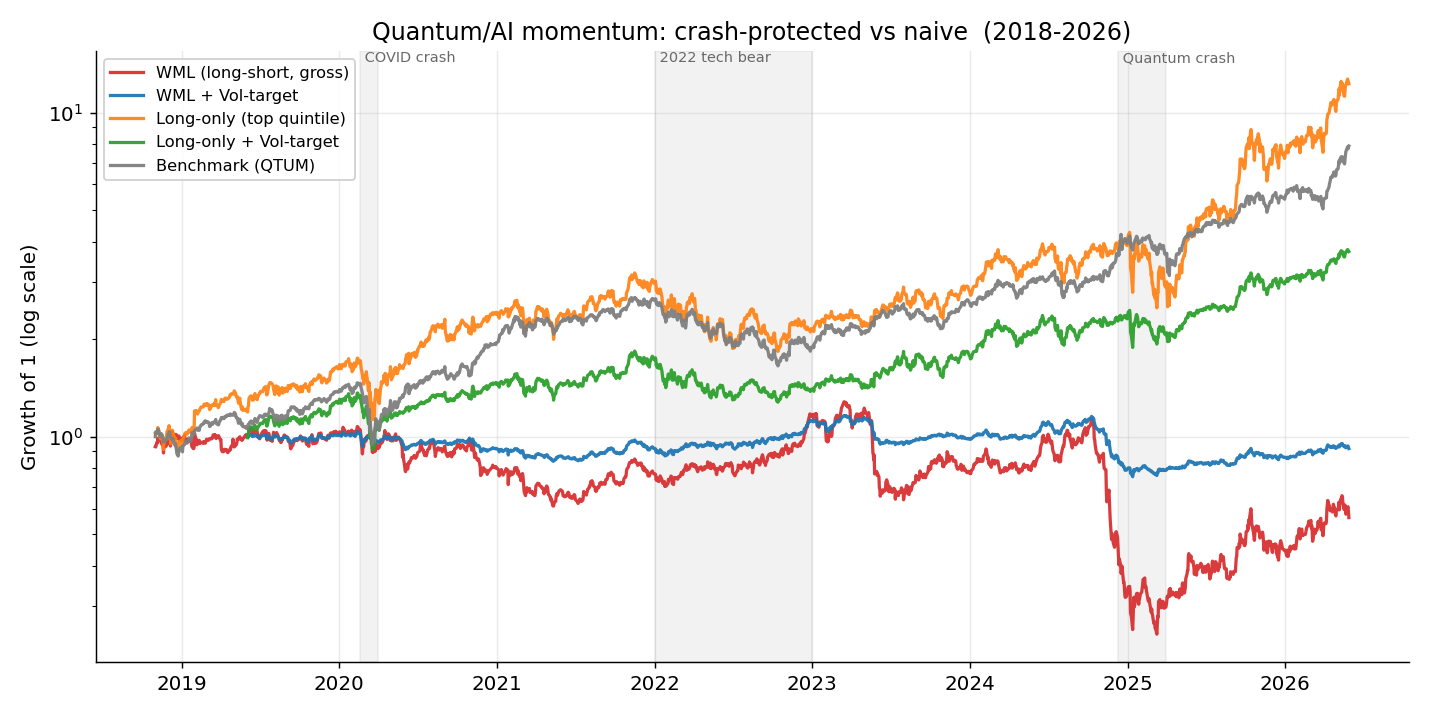

In [3]:
import make_charts; make_charts.main()
display(Image(filename="outputs/fig1_equity_curves.png"))

**Analysis:**
- **Long-only momentum** (orange) and the **QTUM benchmark** (grey) ride the sector boom, but on a *risk-adjusted*
  basis the passive benchmark (Sharpe ≈ **1.1-1.2**) actually **beats** every momentum variant. In a young,
  sentiment-driven bubble sector, "momentum" largely captures **sector beta**, not alpha.
- The **long-short WML book** (red) is a disaster: a near **−81 % maximum drawdown**, bottoming in the wake of the
  2025 quantum crash. This is the momentum crash.

## Result 2 — The anatomy of the quantum momentum crash

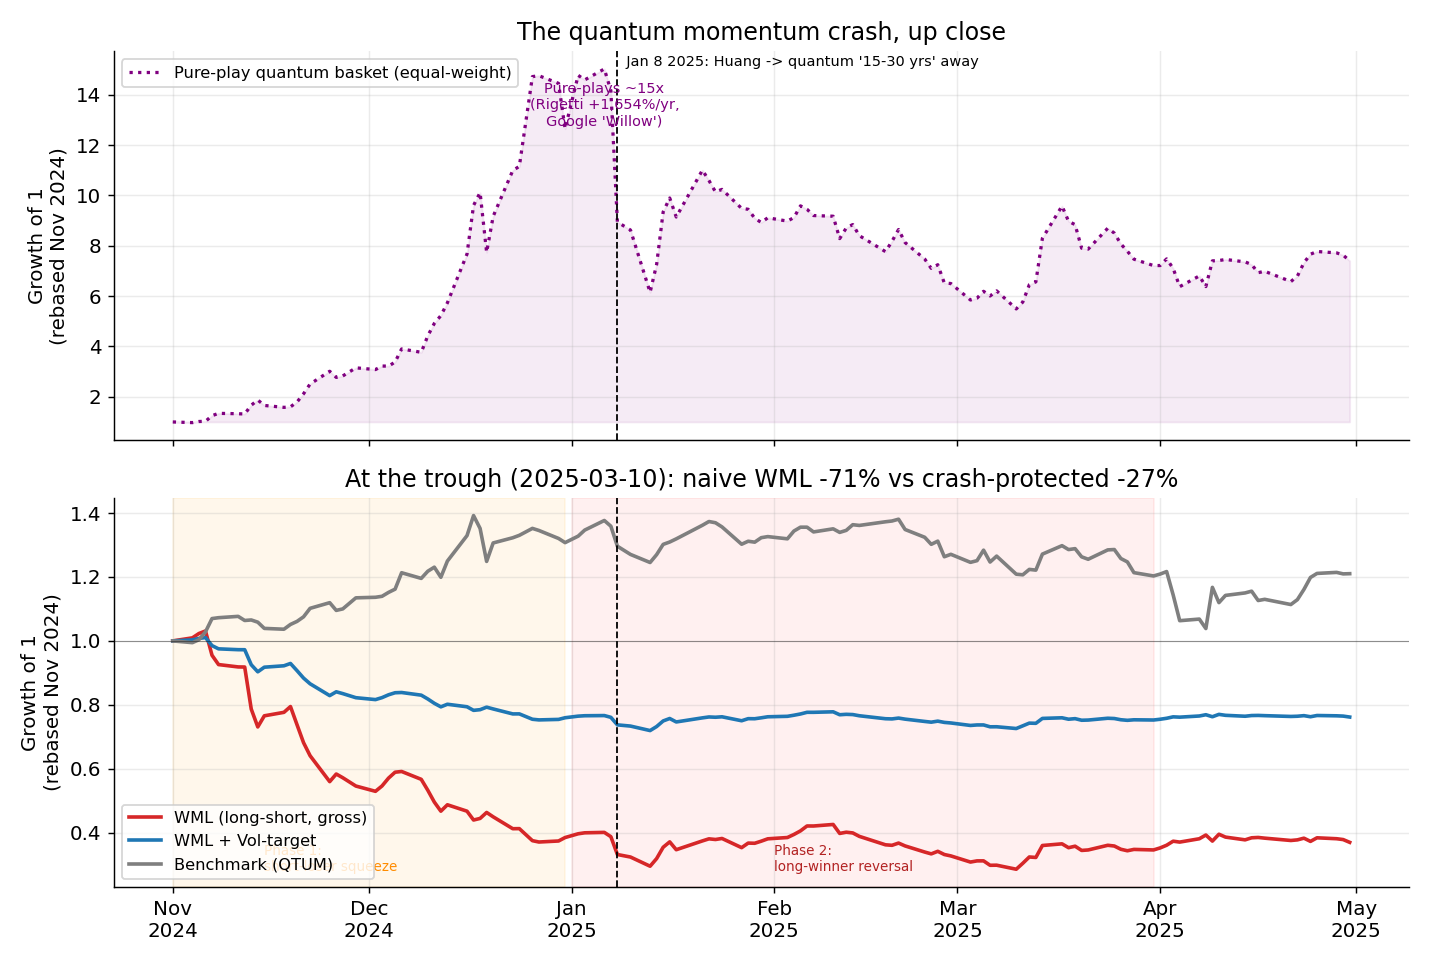

In [ ]:
display(Image(filename="outputs/fig4_quantum_crash_zoom.png"))

### Which names sat in each leg? The crash had TWO sequential mechanisms.

In [4]:
lr = diag["leg_records"]; pp = set(qm.UNIVERSE["pure_play_quantum"])
rows = []
for d in ["2024-10-31","2024-11-30","2024-12-31","2025-01-31"]:
    ix = pd.Timestamp(d)
    if ix in lr.index:
        w = [x for x in lr.loc[ix,"winners"] if x in pp]
        l = [x for x in lr.loc[ix,"losers"]  if x in pp]
        rows.append({"formation": d, "pure-plays LONG (winners)": ", ".join(w) or "—",
                     "pure-plays SHORT (losers)": ", ".join(l) or "—"})
pd.DataFrame(rows).set_index("formation")

,pure-plays LONG (winners),pure-plays SHORT (losers)
formation,,
2024-10-31,—,"LAES, ARQQ, RGTI, QUBT, IONQ"
2024-11-30,—,"LAES, ARQQ"
2024-12-31,"ARQQ, IONQ, RGTI, QBTS, QUBT",LAES
2025-01-31,"LAES, ARQQ, IONQ, QBTS, RGTI, QUBT",—


**Two crashes in one:**

1. **Nov–Dec 2024 — the short-loser squeeze.** Through 2024 the pure-plays were *past losers*, so momentum was
   **short** them. Then they exploded ~15×. Shorting beaten-down names that violently rebound is the **convex,
   option-like loser payoff** Daniel & Moskowitz describe, the WML book is detonated from the short side.
2. **Jan–Mar 2025 — the long-winner reversal.** Now the pure-plays have enormous 12-1 momentum, so the book flips
   to **long them at the very top**, straight into the 8-Jan Huang crash.

**The fix works:** across the full episode (Nov-2024 → Mar-2025) the naive book lost **≈ −66 %**; with
volatility-targeting, **≈ −25 %**. The realised-vol overlay had already *cut leverage to ~0.18×* going into the
crash, exactly when it mattered.

## Result 3 — Why the fix works, and what it costs

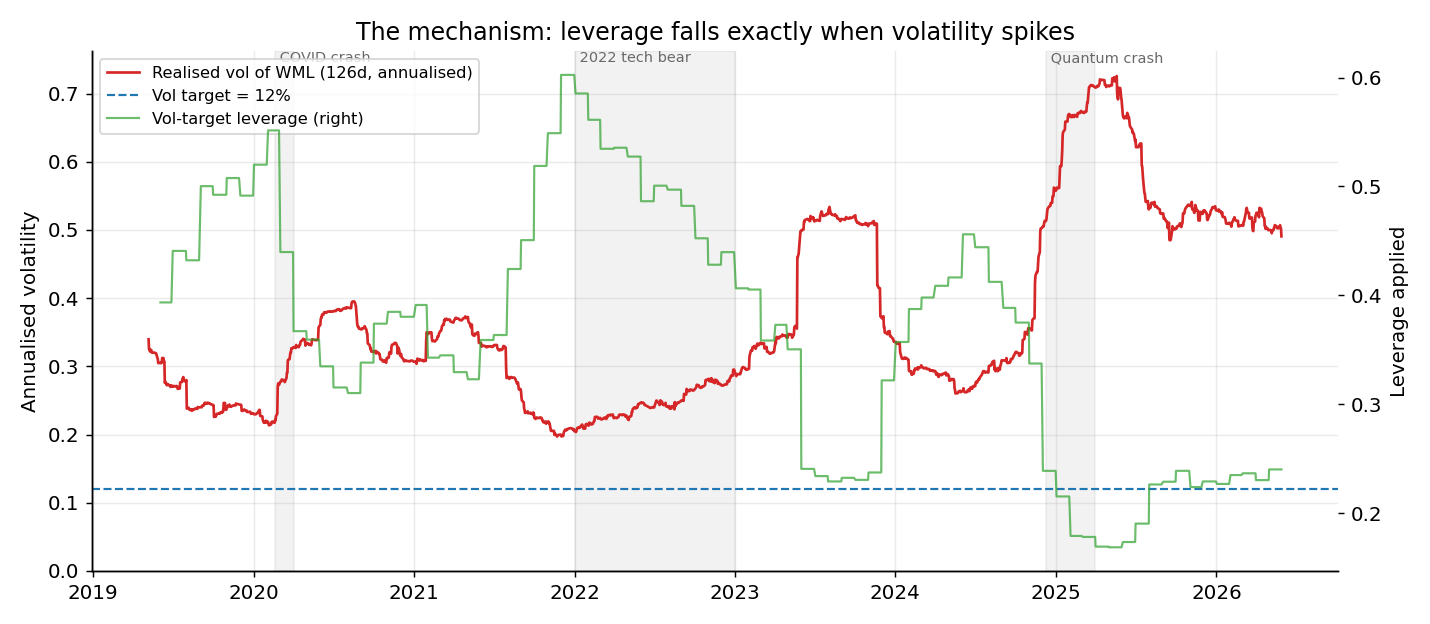

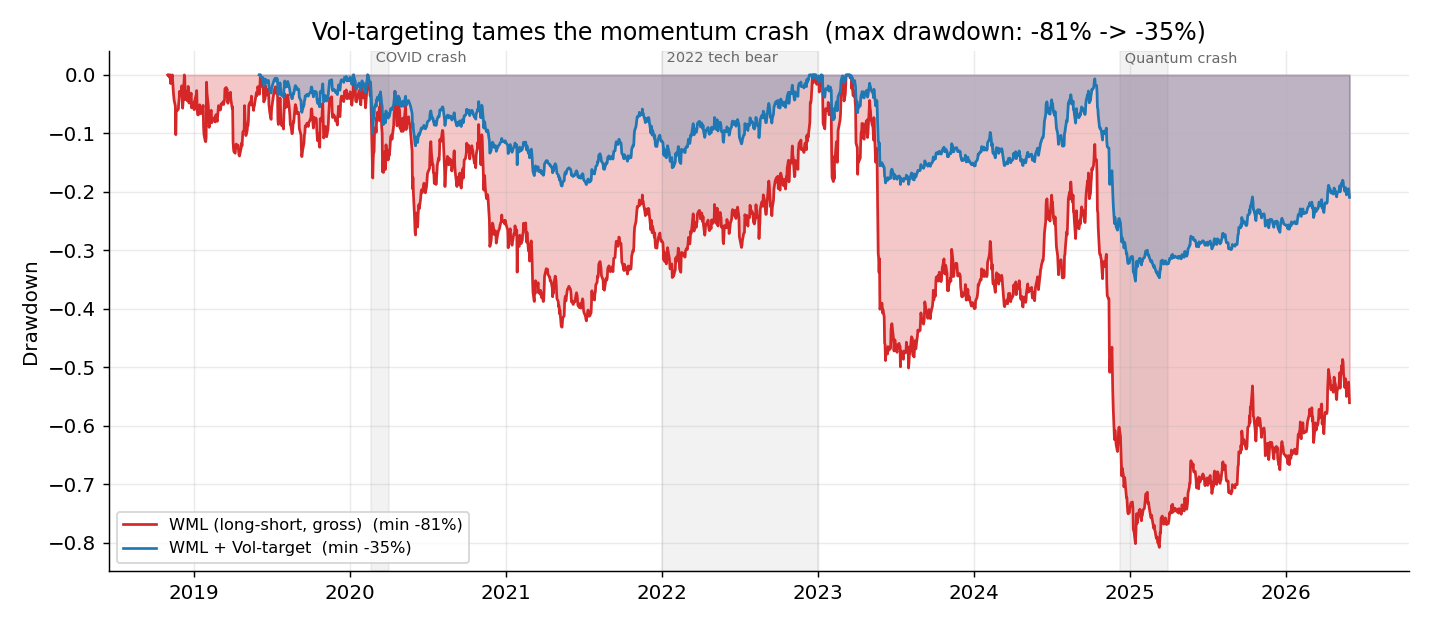

In [5]:
display(Image(filename="outputs/fig3_vol_leverage.png"))
display(Image(filename="outputs/fig2_drawdown.png"))

In [ ]:
# Stress windows + an internal validity check on the vol-target machinery
stress = qm.pd.read_csv("outputs/stress_windows.csv", index_col=0)
display(stress.style.format("{:.1%}"))
vt = results["WML + Vol-target"]
print(f"Vol-target sanity check: realised vol of the WML+VT book = {vt.std()*np.sqrt(252):.1%} "
      f"(target was {qm.VOL_TARGET:.0%}) -> the overlay is calibrated correctly.")

,"WML (long-short, gross)",WML + Vol-target,Long-only (top quintile),Long-only + Vol-target,Benchmark (QTUM)
Quantum crash 2024-11-01..2025-03-31,-65.8%,-25.1%,-20.4%,-6.6%,20.0%
COVID 2020-02-19..2020-03-23,-9.9%,-4.9%,-30.8%,-28.7%,-33.0%
2022 tech bear 2022-01-01..2022-12-31,50.4%,21.3%,-27.6%,-18.9%,-28.8%


Vol-target sanity check: realised vol of the WML+VT book = 13.2% (target was 12%) -> the overlay is calibrated correctly.


- **Mechanism (top chart):** leverage falls *exactly* when the WML book's realised volatility spikes (2022, and
  dramatically in late-2024/2025). Constant-risk targeting = automatic de-risking before crashes.
- **The taming (bottom chart):** maximum drawdown shrinks from **−81 % → −35 %**; full-sample volatility from
  **≈ 40 % → 13 %** (≈ the 12 % target, the machinery is calibrated).
- **The honest cost:** vol-targeting is a **crash shield, not alchemy**. Because this universe has *no* genuine
  long-short momentum premium, the overlay cannot create a positive Sharpe; on the profitable long-only book it
  trades return for safety (Sharpe ≈ 0.97 → 0.81). It buys **survivability**, not free return.

## Conclusions & Limitations

1. **Momentum crashes are real and modern.** The quantum sector delivered a textbook crash in 2024–25, and,
   remarkably, *both* mechanisms in sequence (short-loser squeeze, then long-winner reversal).
2. **Dynamic risk management is essential**: vol-targeting cut the crash loss by ~⅔
   and the max drawdown by more than half.
3. **But context matters.** In a young bubble sector, cross-sectional momentum mostly harvests beta and crash risk;
   the passive sector ETF won on risk-adjusted terms. The textbook *"Sharpe nearly doubles"* result is
   **universe-dependent**, a nuance, honestly owned, that *strengthens* the analysis.

**Limitations:** selection/survivorship bias in a self-built sector basket; ~7-year sample (no 2009);
micro-cap shorting is unrealistic (hence the long-only variant); transaction costs ignored; rebalancing monthly.

***

*Sources: course slides; Tom's Hardware & Fortune (Jan-2025 quantum crash); Jegadeesh–Titman (1993); Daniel–Moskowitz (2016); Barroso & Santa-Clara (2015).*